# Ablation Results

Evaluates four ablation experiments against the IQL baseline:

| `TARGET_ABLATION` | What changes |
|---|---|
| `ablation_bc` | Policy algorithm → Behavioral Cloning |
| `ablation_td3bc` | Policy algorithm → TD3+BC |
| `ablation_reward_only` | Encoder pretrained with reward signal only (no IQL) |
| `ablation_noisy_target` | Remove privileged supervision (no clean-state target) |

**Noise config is auto-derived from environment** — do not edit `ENV_NOISE_DIMS`.

**Cell layout**
- Cell 1 — Imports & project root  
- Cell 2 — Tunable config  
- Cell 3 — Derived method labels (auto-built, do not edit)  
- Cell 4 — Plot style  
- Step 1 — Load metrics  
- Step 2 — Plot helpers  
- Step 3 — Save tables  
- Step 4 — Generate & save figures

In [12]:
from pathlib import Path
import json
import re
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "results").exists():
            return candidate
    raise RuntimeError("Cannot locate project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import (
    RAW_METRICS_DIR,
    FIGURES_ABLATION_DIR,
    TABLES_ABLATION_DIR,
)

print(f"PROJECT_ROOT          = {PROJECT_ROOT}")
print(f"RAW_METRICS_DIR       = {RAW_METRICS_DIR}")
print(f"FIGURES_ABLATION_DIR  = {FIGURES_ABLATION_DIR}")
print(f"TABLES_ABLATION_DIR   = {TABLES_ABLATION_DIR}")

PROJECT_ROOT          = /home/wyuhan/projects/robust-offline-rl-disentanglement
RAW_METRICS_DIR       = /home/wyuhan/projects/robust-offline-rl-disentanglement/results/raw_metrics
FIGURES_ABLATION_DIR  = /home/wyuhan/projects/robust-offline-rl-disentanglement/results/ablation/figures
TABLES_ABLATION_DIR   = /home/wyuhan/projects/robust-offline-rl-disentanglement/results/ablation/tables


In [ ]:
# ============================================================
# Tunable config — modify this cell only
# ============================================================

# Which ablation type to analyze
#   ablation_bc           — Behavioral Cloning policy
#   ablation_td3bc        — TD3+BC policy
#   ablation_reward_only  — encoder pretrained with reward only (no IQL stage)
#   ablation_noisy_target — remove privileged supervision (no_priv)
TARGET_ABLATION = "ablation_td3bc"
# TARGET_ABLATION = "ablation_bc"
# TARGET_ABLATION = "ablation_reward_only"
# TARGET_ABLATION = "ablation_noisy_target"

# Which encoder methods to include
#   Options: "barlow", "dcor", "hsic", "plain"
TARGET_ENCODERS = ["barlow", "dcor", "hsic", "plain"]

# Include raw_noisy / true_only baselines (only meaningful for ablation_bc and ablation_td3bc)
INCLUDE_BASELINES = True

# Overlay IQL (main experiment) results as dashed reference lines
COMPARE_WITH_IQL = True

# Environments
TARGET_ENVS = [
    "halfcheetah-medium-v2",
    # "hopper-medium-v2",
    # "ant-medium-v2",
]

TARGET_SEEDS = [1, 2, 3]

# ── Noise config: auto-derived from env — DO NOT EDIT ────────
ENV_NOISE_DIMS = {
    "halfcheetah-medium-v2": [4, 8, 13, 17],
    "hopper-medium-v2":      [3, 6, 8, 11],
    "ant-medium-v2":         [28, 56, 83, 111],
}
NOISE_SCALES = [0.5, 1.0, 1.5, 2.0]
NOISE_TYPE   = "nonlinear"
# ─────────────────────────────────────────────────────────────

SAVE_FIGURES = True
SAVE_TABLES  = True
SHOW_FIGURES = True

In [14]:
# ============================================================
# Derived method configuration — auto-built from config above
# Edit encoder/baseline logic here; labels/colors are auto-derived from config
# ============================================================

_SUFFIX = {
    "ablation_bc":           "_bc",
    "ablation_td3bc":        "_td3bc",
    "ablation_reward_only":  "_reward_only",
    "ablation_noisy_target": "_no_priv",
}
_ALG_LABEL = {
    "ablation_bc":           "BC",
    "ablation_td3bc":        "TD3+BC",
    "ablation_reward_only":  "Reward Only",
    "ablation_noisy_target": "No Priv",
}
_ENC_KEY = {
    "barlow": "disentangled_barlow",
    "dcor":   "disentangled_dcor",
    "hsic":   "disentangled_hsic",
    "plain":  "plain",
}
_ENC_LABEL = {
    "barlow": "Barlow",
    "dcor":   "dCor",
    "hsic":   "HSIC",
    "plain":  "Plain",
}
# Ablation method colors (solid)
_COLOR_ABL = {
    "barlow": "#e74c3c",
    "dcor":   "#8e44ad",
    "hsic":   "#d35400",
    "plain":  "#3498db",
}
# IQL reference colors (lighter)
_COLOR_IQL = {
    "barlow": "#f1948a",
    "dcor":   "#bb8fce",
    "hsic":   "#e59866",
    "plain":  "#7fb3d3",
}

suffix    = _SUFFIX[TARGET_ABLATION]
alg_label = _ALG_LABEL[TARGET_ABLATION]

# Build method_labels and palette for ablation methods
method_labels = {}
palette       = {}
global_order  = []

for enc in TARGET_ENCODERS:
    key   = _ENC_KEY[enc] + suffix
    label = f"{_ENC_LABEL[enc]} ({alg_label})"
    method_labels[key] = label
    palette[label]     = _COLOR_ABL.get(enc, "#aaaaaa")
    global_order.append(label)

# Optional baselines for bc / td3bc
if INCLUDE_BASELINES and TARGET_ABLATION in ("ablation_bc", "ablation_td3bc"):
    method_labels[f"raw_noisy{suffix}"]  = f"Raw Noisy ({alg_label})"
    method_labels[f"true_only{suffix}"]  = f"No Noise ({alg_label})"
    palette[f"Raw Noisy ({alg_label})"]  = "#95a5a6"
    palette[f"No Noise ({alg_label})"]   = "#2c3e50"
    global_order += [f"Raw Noisy ({alg_label})", f"No Noise ({alg_label})"]

# IQL comparison methods
iql_labels = {}
if COMPARE_WITH_IQL:
    for enc in TARGET_ENCODERS:
        key   = _ENC_KEY[enc]
        label = f"{_ENC_LABEL[enc]} (IQL)"
        iql_labels[key] = label
        palette[label]  = _COLOR_IQL.get(enc, "#cccccc")
        global_order.append(label)


# Add raw_noisy (IQL) baseline for reward_only / noisy_target ablations
if INCLUDE_BASELINES and TARGET_ABLATION in ("ablation_reward_only", "ablation_noisy_target"):
    iql_labels["raw_noisy"] = "Raw Noisy (IQL)"
    palette["Raw Noisy (IQL)"] = "#95a5a6"
    global_order.append("Raw Noisy (IQL)")

all_method_labels = {**method_labels, **iql_labels}
ablation_keys     = list(method_labels.keys())
iql_keys          = list(iql_labels.keys())

print(f"Ablation : {TARGET_ABLATION}  ({alg_label})")
print(f"Ablation methods : {ablation_keys}")
print(f"IQL reference    : {iql_keys}")

Ablation : ablation_noisy_target  (No Priv)
Ablation methods : ['disentangled_barlow_no_priv', 'disentangled_dcor_no_priv', 'disentangled_hsic_no_priv', 'plain_no_priv']
IQL reference    : ['disentangled_barlow', 'disentangled_dcor', 'disentangled_hsic', 'plain', 'raw_noisy']


In [15]:
sns.set_theme(style="whitegrid", font_scale=1.1)

## Step 1 — Load metrics

In [16]:
def scale_to_tag(v: float) -> str:
    return str(v).replace(".", "p")


def _infer_method(norm: str, keys) -> str:
    for k in sorted(keys, key=len, reverse=True):
        if f"/{k}/" in norm:
            return k
    return ""


def _infer_env(path: Path, envs) -> str:
    parts = set(path.parts)
    for e in envs:
        if e in parts:
            return e
    return ""


def load_metrics(
    raw_metrics_dir: Path,
    ablation_keys,
    iql_keys,
    target_seeds,
    target_envs,
    env_noise_dims,
    noise_scales,
    noise_type,
):
    """
    Returns
    -------
    df_noisy  : records with noise_dim / noise_scale
    df_oracle : records without noise params — true_only variants only
    """
    all_keys = set(ablation_keys) | set(iql_keys)

    noisy, oracle = [], []
    seen = set()

    for fp in raw_metrics_dir.rglob("*.json"):
        key = str(fp.resolve())
        if key in seen:
            continue
        seen.add(key)

        try:
            data = json.loads(fp.read_text(encoding="utf-8"))
        except Exception:
            continue

        score = data.get("normalized_score")
        if score is None:
            continue

        norm = str(fp.parent).replace("\\", "/")
        cfg  = data.get("data_config", {})

        method = (
            data.get("method") or data.get("group")
            or _infer_method(norm, all_keys)
        )
        if method not in all_keys:
            continue

        env = (
            data.get("env_name") or data.get("env")
            or cfg.get("env_name") or _infer_env(fp, target_envs)
        )
        if env not in target_envs:
            continue

        seed = data.get("seed", cfg.get("seed"))
        if seed is None:
            m = re.search(r"seed_?(\d+)", norm, re.IGNORECASE)
            seed = int(m.group(1)) if m else None
        else:
            seed = int(seed)
        if seed not in target_seeds:
            continue

        nd    = data.get("noise_dim",   cfg.get("noise_dim"))
        ns    = data.get("noise_scale", cfg.get("noise_scale"))
        ntype = data.get("noise_type",  cfg.get("noise_type"))

        # Oracle record: only true_only variants have no noise params by design.
        # Other methods missing noise_type are old/legacy files — skip them.
        if nd is None or ns is None or ntype is None:
            if method.startswith("true_only"):
                oracle.append({"Method": method, "Env": env,
                               "Seed": seed, "Score": float(score)})
            continue

        if ntype != noise_type:
            continue
        env_dims = env_noise_dims.get(env, [])
        if int(nd) not in env_dims:
            continue
        if float(ns) not in noise_scales:
            continue

        noisy.append({
            "Method": method, "Env": env,
            "Dim": int(nd), "Scale": float(ns),
            "Type": ntype, "Seed": seed,
            "Score": float(score),
        })

    df_noisy  = pd.DataFrame(noisy)
    df_oracle = (
        pd.DataFrame(oracle)
        .drop_duplicates(subset=["Method", "Env", "Seed"], keep="first")
        .reset_index(drop=True)
        if oracle else pd.DataFrame()
    )
    return df_noisy, df_oracle

In [17]:
df_noisy, df_oracle = load_metrics(
    raw_metrics_dir=RAW_METRICS_DIR,
    ablation_keys=ablation_keys,
    iql_keys=iql_keys,
    target_seeds=TARGET_SEEDS,
    target_envs=TARGET_ENVS,
    env_noise_dims=ENV_NOISE_DIMS,
    noise_scales=NOISE_SCALES,
    noise_type=NOISE_TYPE,
)

seed_tag = "_".join(str(s) for s in sorted(TARGET_SEEDS))

print(f"Noise-sweep records : {len(df_noisy)}")
print(f"Oracle records      : {len(df_oracle)}")
if not df_noisy.empty:
    print("Methods found:", sorted(df_noisy['Method'].unique()))
    print("Envs found:   ", sorted(df_noisy['Env'].unique()))
if not df_oracle.empty:
    print("Oracle methods:", sorted(df_oracle['Method'].unique()))

df_noisy.head()

Noise-sweep records : 432
Oracle records      : 0
Methods found: ['disentangled_barlow', 'disentangled_barlow_no_priv', 'disentangled_dcor', 'disentangled_dcor_no_priv', 'disentangled_hsic', 'disentangled_hsic_no_priv', 'plain', 'plain_no_priv', 'raw_noisy']
Envs found:    ['halfcheetah-medium-v2']


,Method,Env,Dim,Scale,Type,Seed,Score
0,disentangled_hsic_no_priv,halfcheetah-medium-v2,8,1.5,nonlinear,1,32.749241
1,disentangled_hsic_no_priv,halfcheetah-medium-v2,8,1.5,nonlinear,3,34.967665
2,disentangled_hsic_no_priv,halfcheetah-medium-v2,8,1.5,nonlinear,2,31.526684
3,disentangled_hsic_no_priv,halfcheetah-medium-v2,13,1.0,nonlinear,1,34.056802
4,disentangled_hsic_no_priv,halfcheetah-medium-v2,13,1.0,nonlinear,3,37.447765


## Step 2 — Plot helpers

In [18]:
def _add_labels(df, label_map):
    df = df.copy()
    df["Label"] = df["Method"].map(label_map)
    return df


def _present_order(df, global_order):
    present = set(df["Label"].dropna())
    return [m for m in global_order if m in present]


def plot_bar(
    sub_df, x_col, x_label, title,
    all_method_labels, global_order, palette,
    oracle_lines=None,   # dict: {label: mean_score} — shown as hlines
    save_path=None, show=True,
):
    if sub_df.empty:
        return
    plot_df = _add_labels(sub_df, all_method_labels)
    order   = _present_order(plot_df, global_order)
    plot_df["Label"] = pd.Categorical(plot_df["Label"], categories=order, ordered=True)

    n_x, n_m = len(plot_df[x_col].unique()), len(order)
    fig, ax = plt.subplots(figsize=(max(8, n_x * n_m * 0.5), 6))
    sns.barplot(
        data=plot_df, x=x_col, y="Score", hue="Label",
        palette=palette, edgecolor="black", linewidth=1.2,
        capsize=0.05, ax=ax,
    )
    for patch in ax.patches:
        h = patch.get_height()
        if pd.notna(h) and h > 0:
            ax.annotate(f"{h:.1f}",
                        (patch.get_x() + patch.get_width() / 2, h),
                        ha="center", va="bottom",
                        xytext=(0, 4), textcoords="offset points",
                        fontsize=8, fontweight="bold", rotation=90)

    if oracle_lines:
        for lbl, val in oracle_lines.items():
            ax.axhline(val, linestyle="--", linewidth=1.5,
                       color=palette.get(lbl, "gray"), label=lbl, alpha=0.8)
        ax.legend(title="Method", fontsize=9, title_fontsize=10,
                  bbox_to_anchor=(1.02, 1), loc="upper left")

    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel("Normalized D4RL Score", fontsize=12)
    scores = plot_df["Score"][plot_df["Score"] > 0]
    if not scores.empty:
        ax.set_ylim(max(0, scores.min() - 10), plot_df["Score"].max() + 15)
    plt.tight_layout()

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show() if show else plt.close()


def plot_line(
    sub_df, x_col, x_label, title,
    all_method_labels, global_order, palette,
    oracle_lines=None,
    save_path=None, show=True,
):
    if sub_df.empty:
        return
    plot_df = _add_labels(sub_df, all_method_labels)
    order   = _present_order(plot_df, global_order)

    stats = (
        plot_df.groupby(["Label", x_col])["Score"]
        .agg(["mean", "std"]).reset_index()
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    for label in order:
        cur = stats[stats["Label"] == label].sort_values(x_col)
        if cur.empty:
            continue
        # IQL reference: dashed line; ablation: solid
        ls = "--" if "(IQL)" in label else "-"
        ax.errorbar(
            cur[x_col], cur["mean"], yerr=cur["std"].fillna(0),
            marker="o", capsize=4, linewidth=2, markersize=5,
            linestyle=ls, label=label,
            color=palette.get(label, "#aaaaaa"),
        )

    if oracle_lines:
        for lbl, val in oracle_lines.items():
            ax.axhline(val, linestyle=":", linewidth=1.5,
                       color=palette.get(lbl, "gray"), label=lbl, alpha=0.8)

    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel("Normalized D4RL Score", fontsize=12)
    ax.set_xticks(sorted(stats[x_col].unique()))
    means = stats["mean"]
    if not means.empty:
        ax.set_ylim(max(0, means[means > 0].min() - 10), means.max() + 15)
    ax.legend(title="Method", fontsize=9, title_fontsize=10,
              bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show() if show else plt.close()

## Step 3 — Save tables

In [19]:
def save_tables(df_noisy, df_oracle, table_dir: Path, ablation_name, seed_tag):
    table_dir.mkdir(parents=True, exist_ok=True)

    if not df_noisy.empty:
        p = table_dir / f"records_{ablation_name}_seeds_{seed_tag}.csv"
        df_noisy.to_csv(p, index=False)
        print(f"Saved records  → {p}")

        summary = (
            df_noisy.groupby(["Method", "Env", "Dim", "Scale", "Type"])["Score"]
            .agg(mean="mean", std="std", n="count")
            .reset_index()
        )
        p = table_dir / f"summary_{ablation_name}_seeds_{seed_tag}.csv"
        summary.to_csv(p, index=False)
        print(f"Saved summary  → {p}")

    if not df_oracle.empty:
        p = table_dir / f"oracle_{ablation_name}_seeds_{seed_tag}.csv"
        df_oracle.to_csv(p, index=False)
        print(f"Saved oracle   → {p}")

In [20]:
if SAVE_TABLES:
    for env in TARGET_ENVS:
        d_n = df_noisy[df_noisy["Env"] == env]   if not df_noisy.empty  else pd.DataFrame()
        d_o = df_oracle[df_oracle["Env"] == env]  if not df_oracle.empty else pd.DataFrame()
        if d_n.empty and d_o.empty:
            print(f"[WARN] No data for {env}, skipping.")
            continue
        save_tables(d_n, d_o, TABLES_ABLATION_DIR / env, TARGET_ABLATION, seed_tag)
else:
    print("Table export disabled.")

Saved records  → /home/wyuhan/projects/robust-offline-rl-disentanglement/results/ablation/tables/halfcheetah-medium-v2/records_ablation_noisy_target_seeds_1_2_3.csv
Saved summary  → /home/wyuhan/projects/robust-offline-rl-disentanglement/results/ablation/tables/halfcheetah-medium-v2/summary_ablation_noisy_target_seeds_1_2_3.csv


## Step 4 — Generate & save figures

In [21]:
def build_oracle_lines(df_oracle, env, all_method_labels, palette):
    """Build {display_label: mean_score} for oracle reference lines."""
    if df_oracle.empty:
        return {}
    d = df_oracle[df_oracle["Env"] == env]
    result = {}
    for method, grp in d.groupby("Method"):
        label = all_method_labels.get(method)
        if label:
            result[label] = float(grp["Score"].mean())
    return result


def generate_figures(
    df_noisy, df_oracle, env,
    env_noise_dims, noise_scales, noise_type,
    fig_dir: Path,
    ablation_name,
    all_method_labels, global_order, palette,
    save=True, show=True,
):
    target_dims = env_noise_dims.get(env, [])
    oracle_lines = build_oracle_lines(df_oracle, env, all_method_labels, palette)

    bar_dir  = fig_dir / "bar"
    line_dir = fig_dir / "line"

    # Scale sweep: fix dim, x-axis = scale
    for dim in target_dims:
        sub = df_noisy[df_noisy["Dim"] == dim]
        if sub.empty:
            continue
        title = f"Scale Sweep  |  noise_dim={dim}  |  {ablation_name}"
        plot_bar(
            sub, "Scale", "Noise Scale", title,
            all_method_labels, global_order, palette, oracle_lines,
            save_path=bar_dir / f"scale_sweep_{ablation_name}_dim_{dim}.png" if save else None,
            show=show,
        )
        plot_line(
            sub, "Scale", "Noise Scale", title,
            all_method_labels, global_order, palette, oracle_lines,
            save_path=line_dir / f"scale_curve_{ablation_name}_dim_{dim}.png" if save else None,
            show=show,
        )

    # Dim sweep: fix scale, x-axis = dim
    for scale in noise_scales:
        sub = df_noisy[df_noisy["Scale"] == scale]
        if sub.empty:
            continue
        stag  = scale_to_tag(scale)
        title = f"Dim Sweep  |  noise_scale={scale}  |  {ablation_name}"
        plot_bar(
            sub, "Dim", "Noise Dimension", title,
            all_method_labels, global_order, palette, oracle_lines,
            save_path=bar_dir / f"dim_sweep_{ablation_name}_scale_{stag}.png" if save else None,
            show=show,
        )
        plot_line(
            sub, "Dim", "Noise Dimension", title,
            all_method_labels, global_order, palette, oracle_lines,
            save_path=line_dir / f"dim_curve_{ablation_name}_scale_{stag}.png" if save else None,
            show=show,
        )


--- halfcheetah-medium-v2  |  ablation_noisy_target ---
  (no oracle records found)


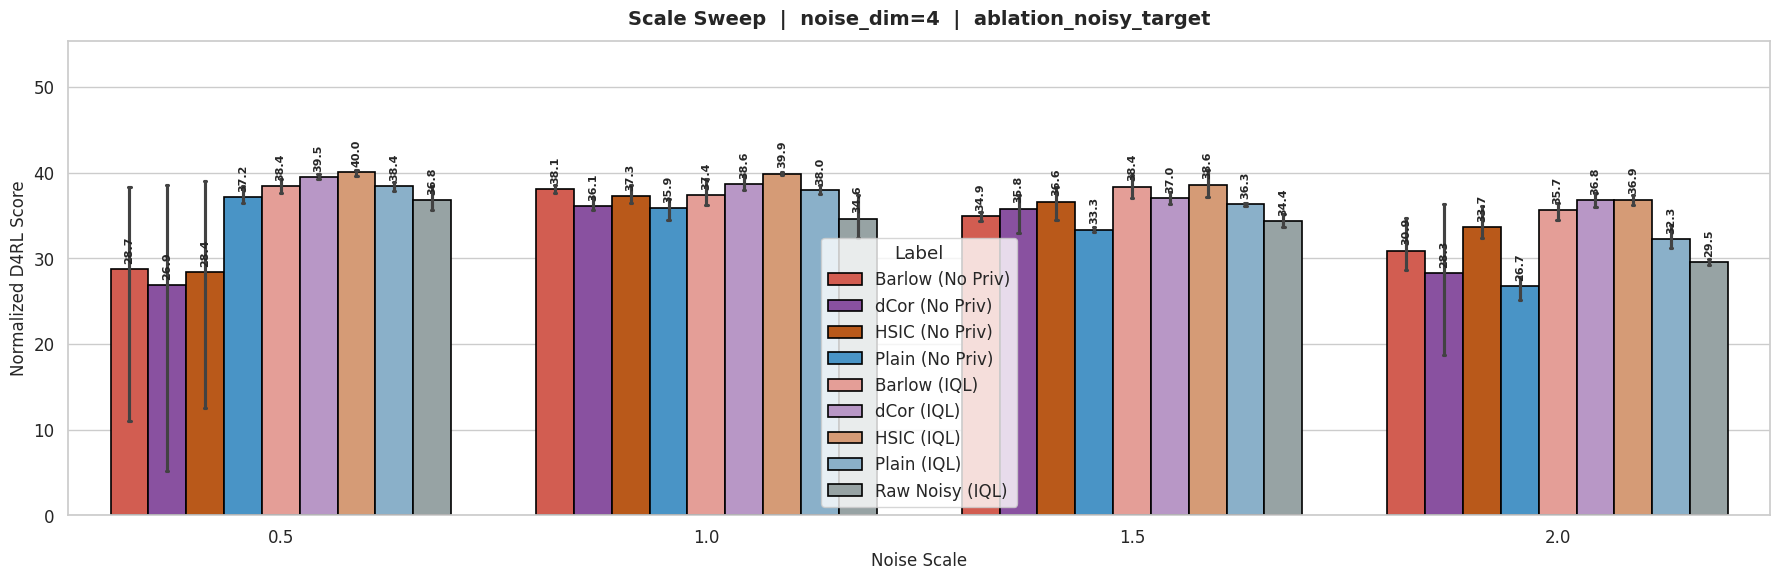

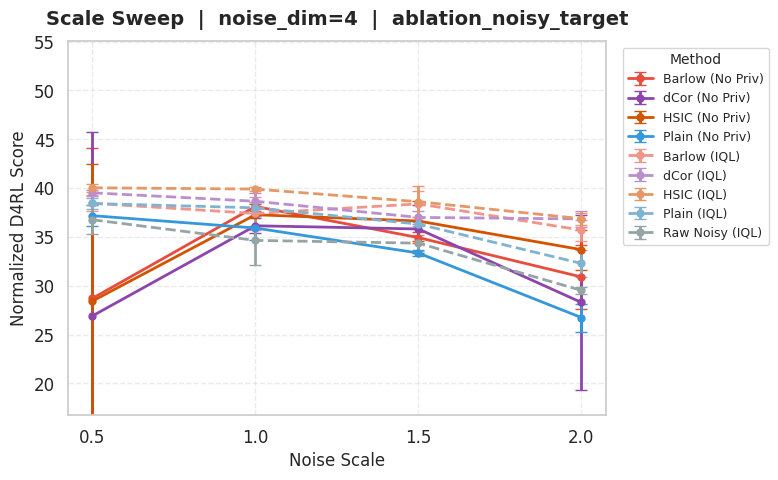

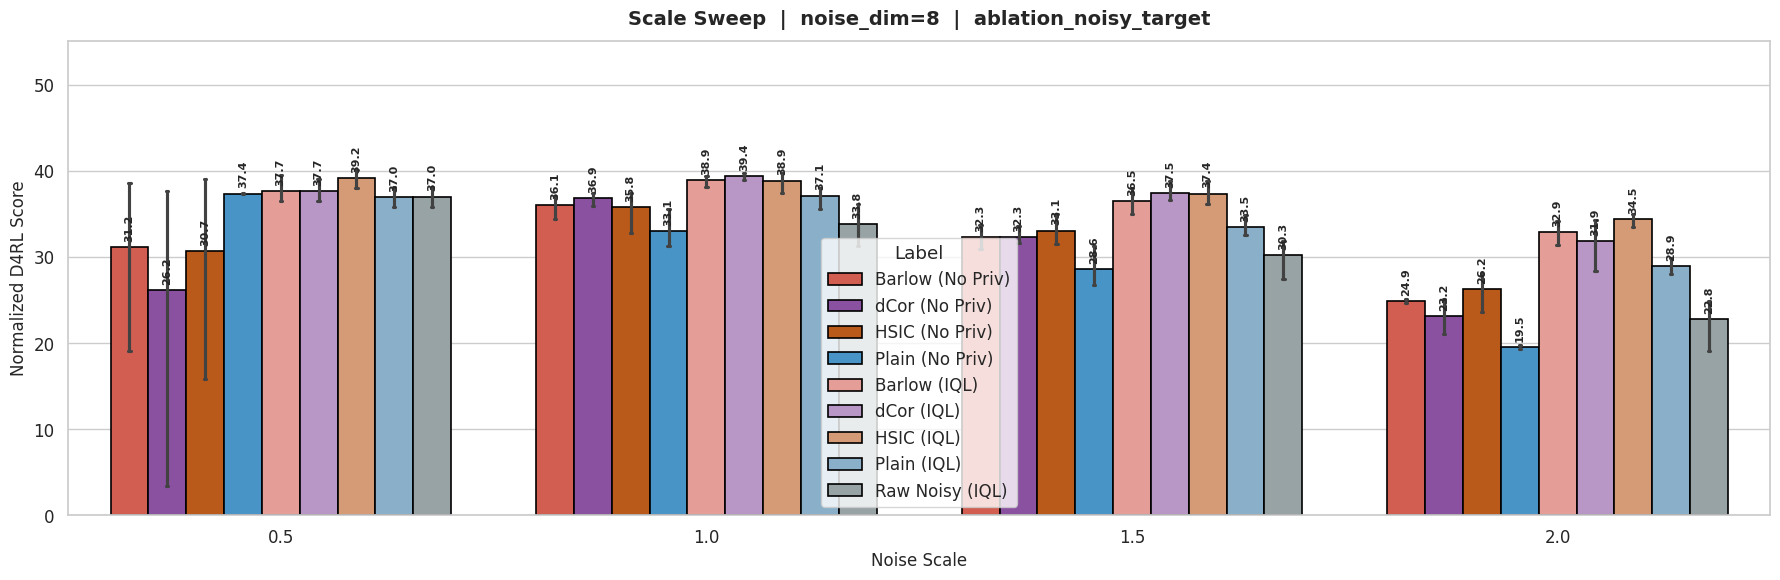

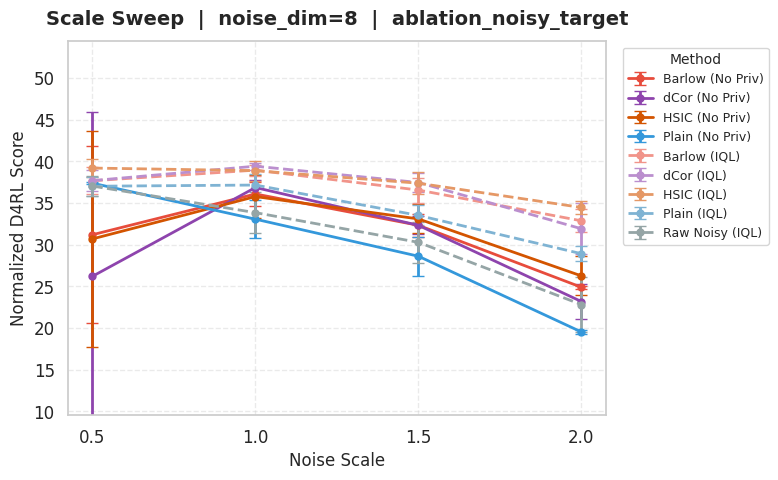

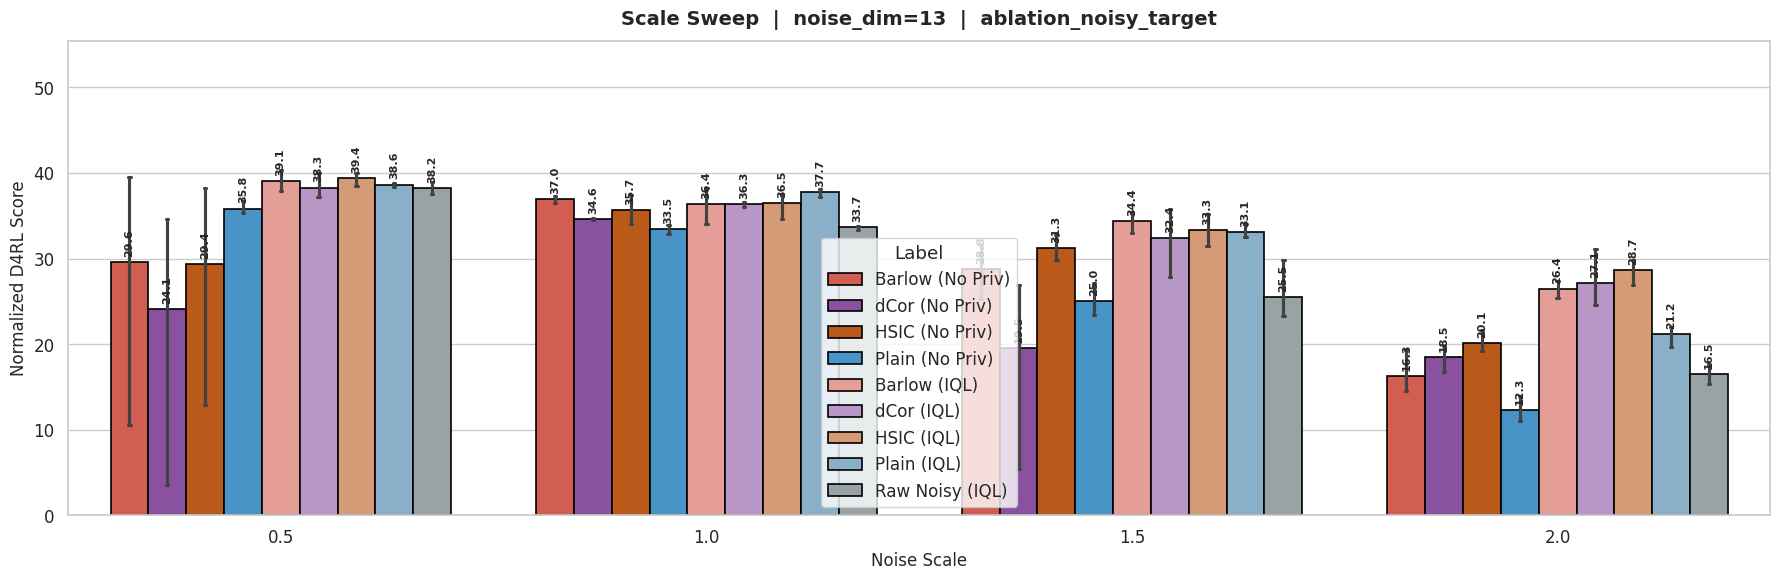

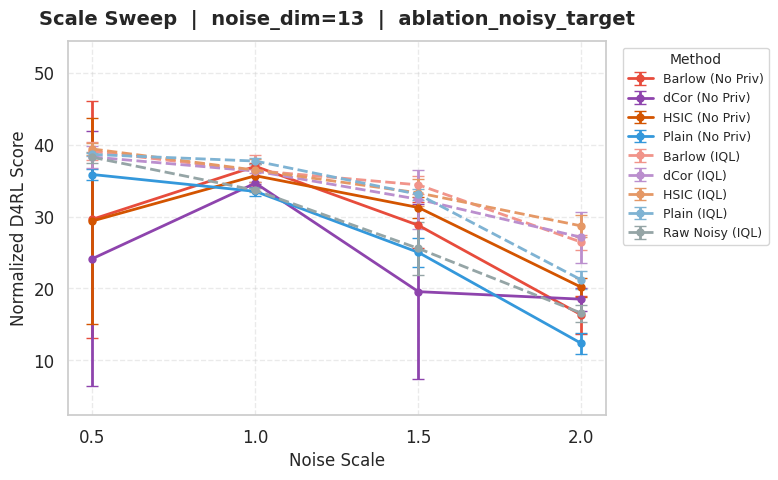

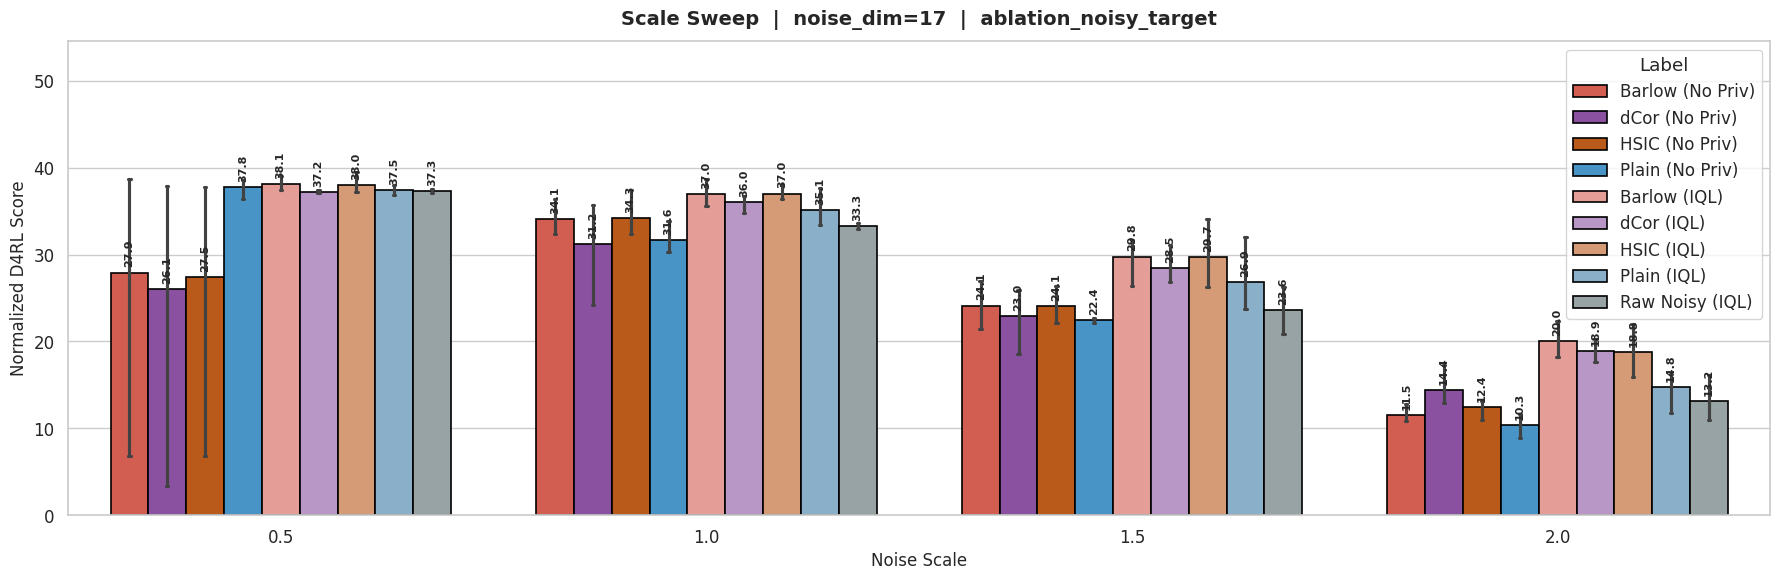

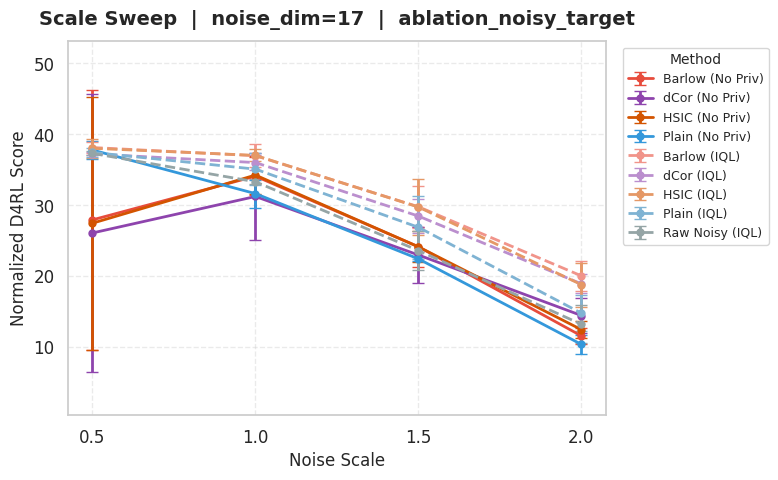

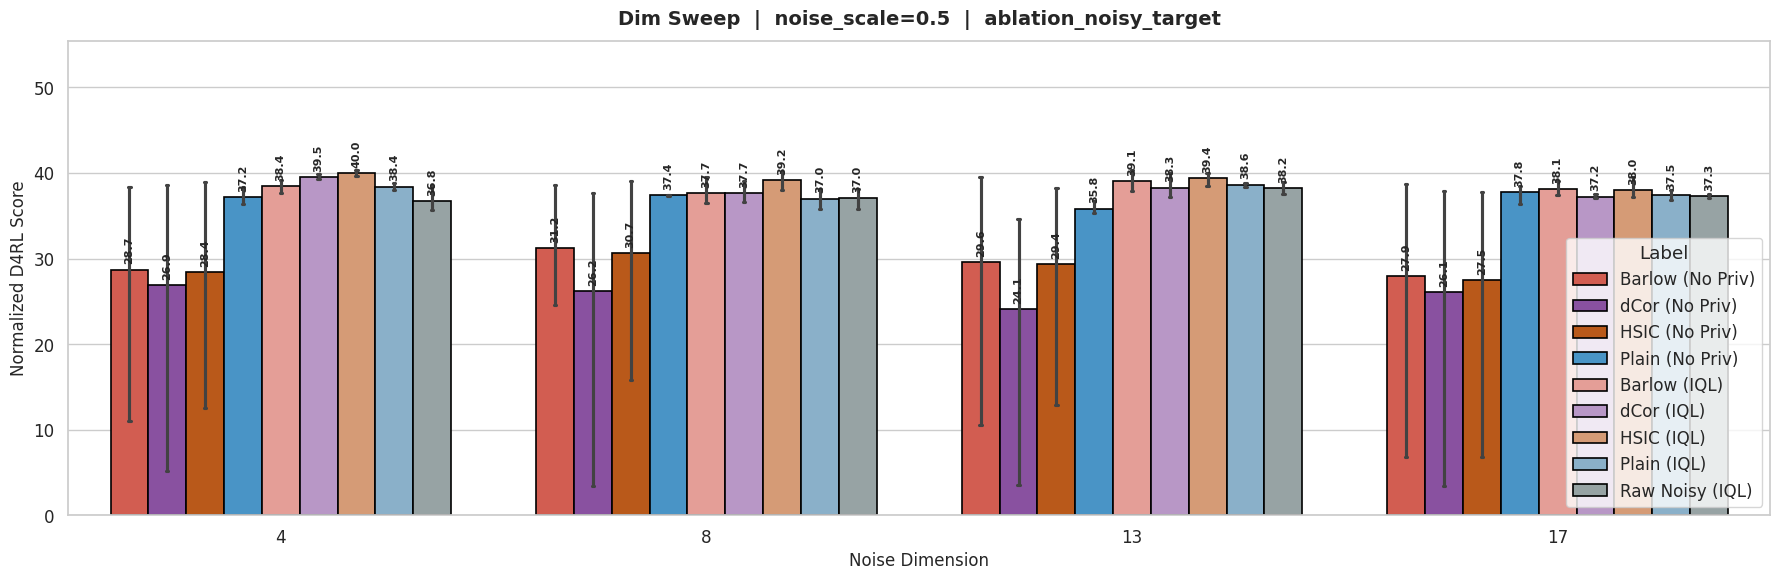

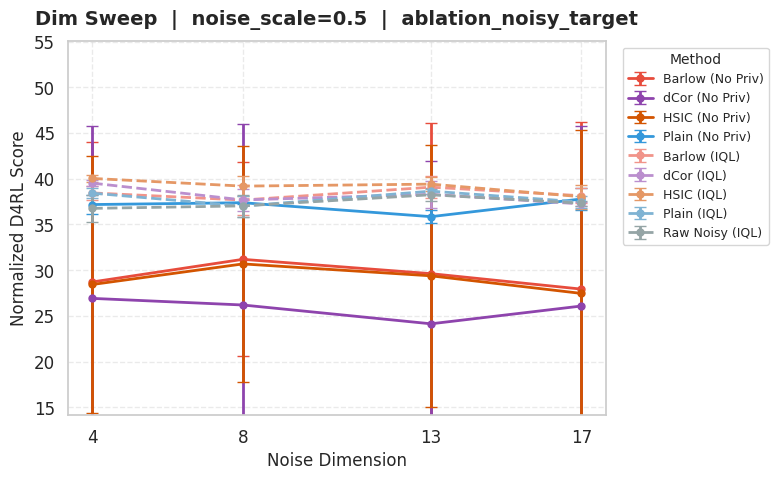

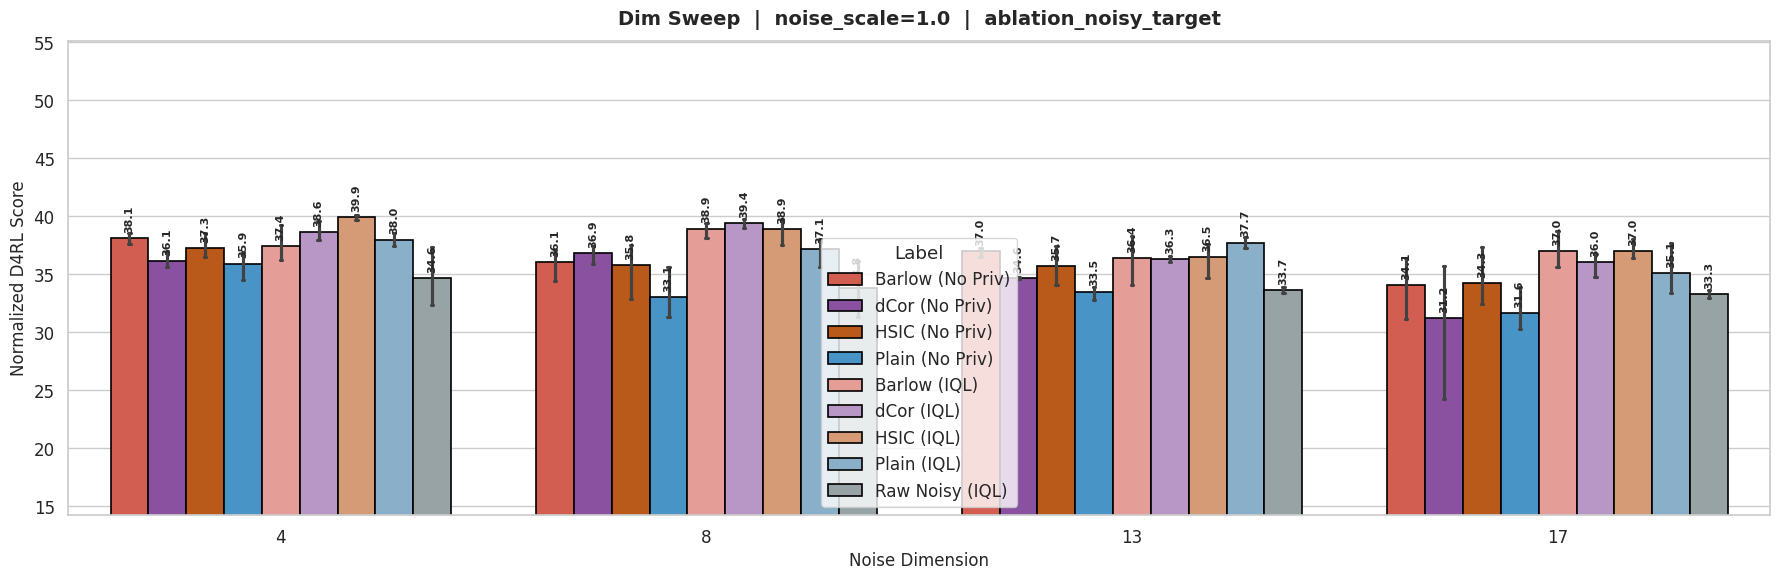

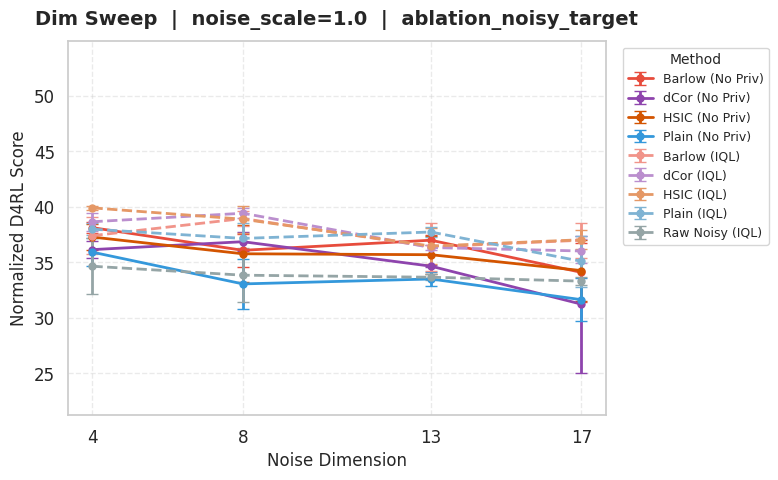

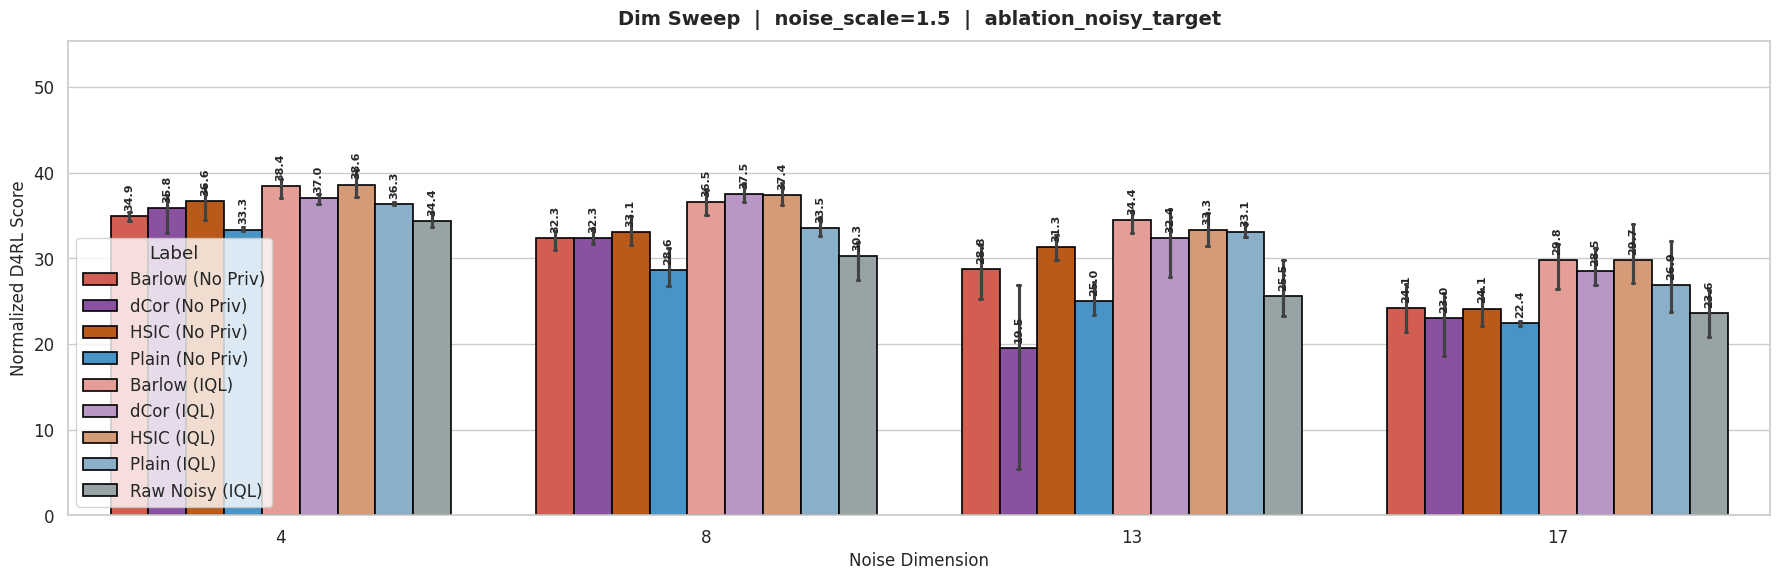

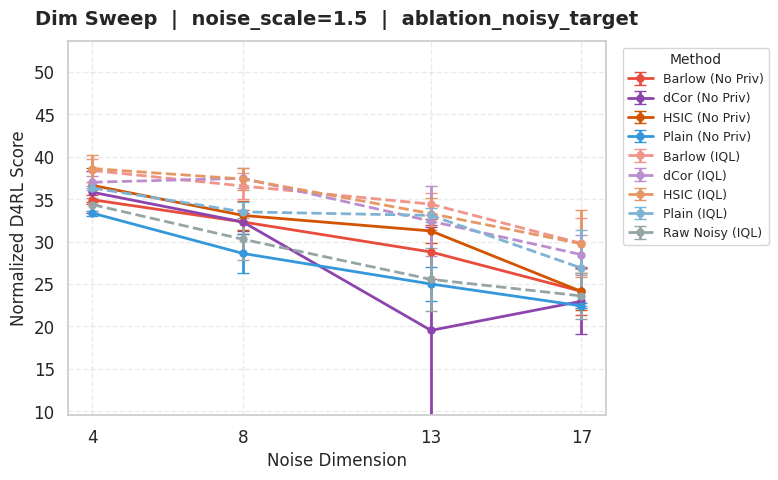

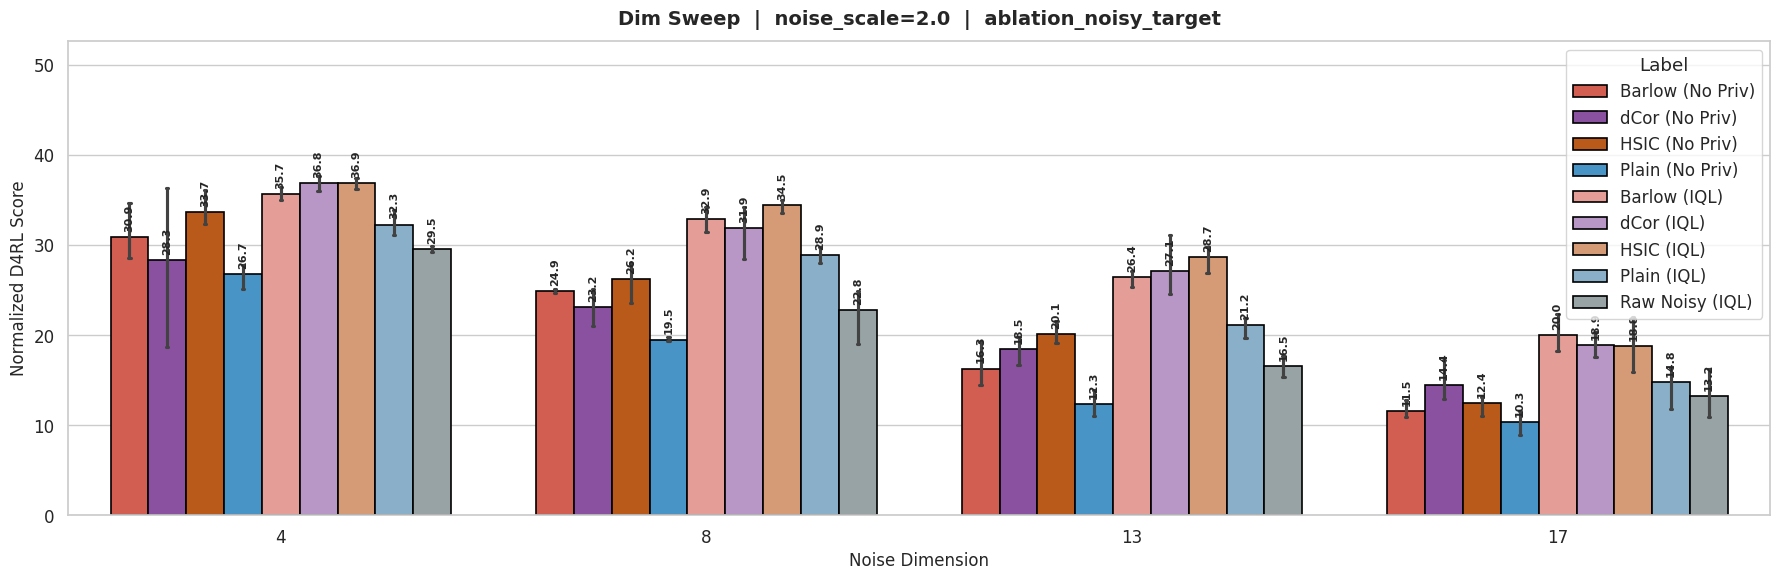

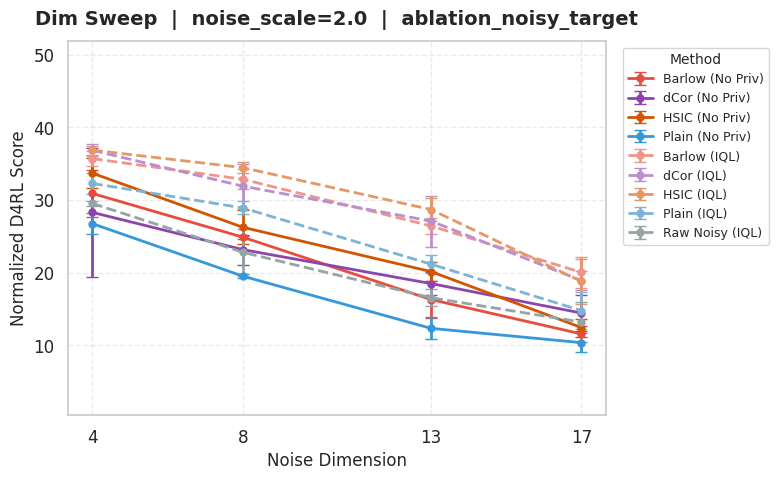

In [22]:
for env in TARGET_ENVS:
    d_n = df_noisy[df_noisy["Env"] == env]   if not df_noisy.empty  else pd.DataFrame()
    d_o = df_oracle[df_oracle["Env"] == env]  if not df_oracle.empty else pd.DataFrame()

    if d_n.empty:
        print(f"[WARN] No noise-sweep data for {env}, skipping figures.")
        continue

    fig_dir = FIGURES_ABLATION_DIR / env / TARGET_ABLATION
    print(f"\n--- {env}  |  {TARGET_ABLATION} ---")
    if d_o.empty:
        print("  (no oracle records found)")

    generate_figures(
        df_noisy=d_n,
        df_oracle=d_o,
        env=env,
        env_noise_dims=ENV_NOISE_DIMS,
        noise_scales=NOISE_SCALES,
        noise_type=NOISE_TYPE,
        fig_dir=fig_dir,
        ablation_name=TARGET_ABLATION,
        all_method_labels=all_method_labels,
        global_order=global_order,
        palette=palette,
        save=SAVE_FIGURES,
        show=SHOW_FIGURES,
    )